In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv(r"C:\Users\Abhishek Verma\Downloads\credit_risk_dataset.csv")

In [3]:
df.shape

(1000, 8)

In [4]:
df.head()

,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Education_Level,Housing_Status,Default
0,59,52154.0,11276,823,15,Bachelors,Own,0
1,49,116646.0,43663,315,5,PhD,Own,0
2,35,61157.0,18994,428,8,Masters,Own,1
3,63,52154.0,28499,408,26,Bachelors,Rent,0
4,28,148876.0,28040,832,3,Masters,Own,1


In [5]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [6]:
df.head()

,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Education_Level,Housing_Status,Default
0,59,52154.0,11276,823,15,Bachelors,Own,0
1,49,116646.0,43663,315,5,PhD,Own,0
2,35,61157.0,18994,428,8,Masters,Own,1
3,63,52154.0,28499,408,26,Bachelors,Rent,0
4,28,148876.0,28040,832,3,Masters,Own,1


<Axes: >

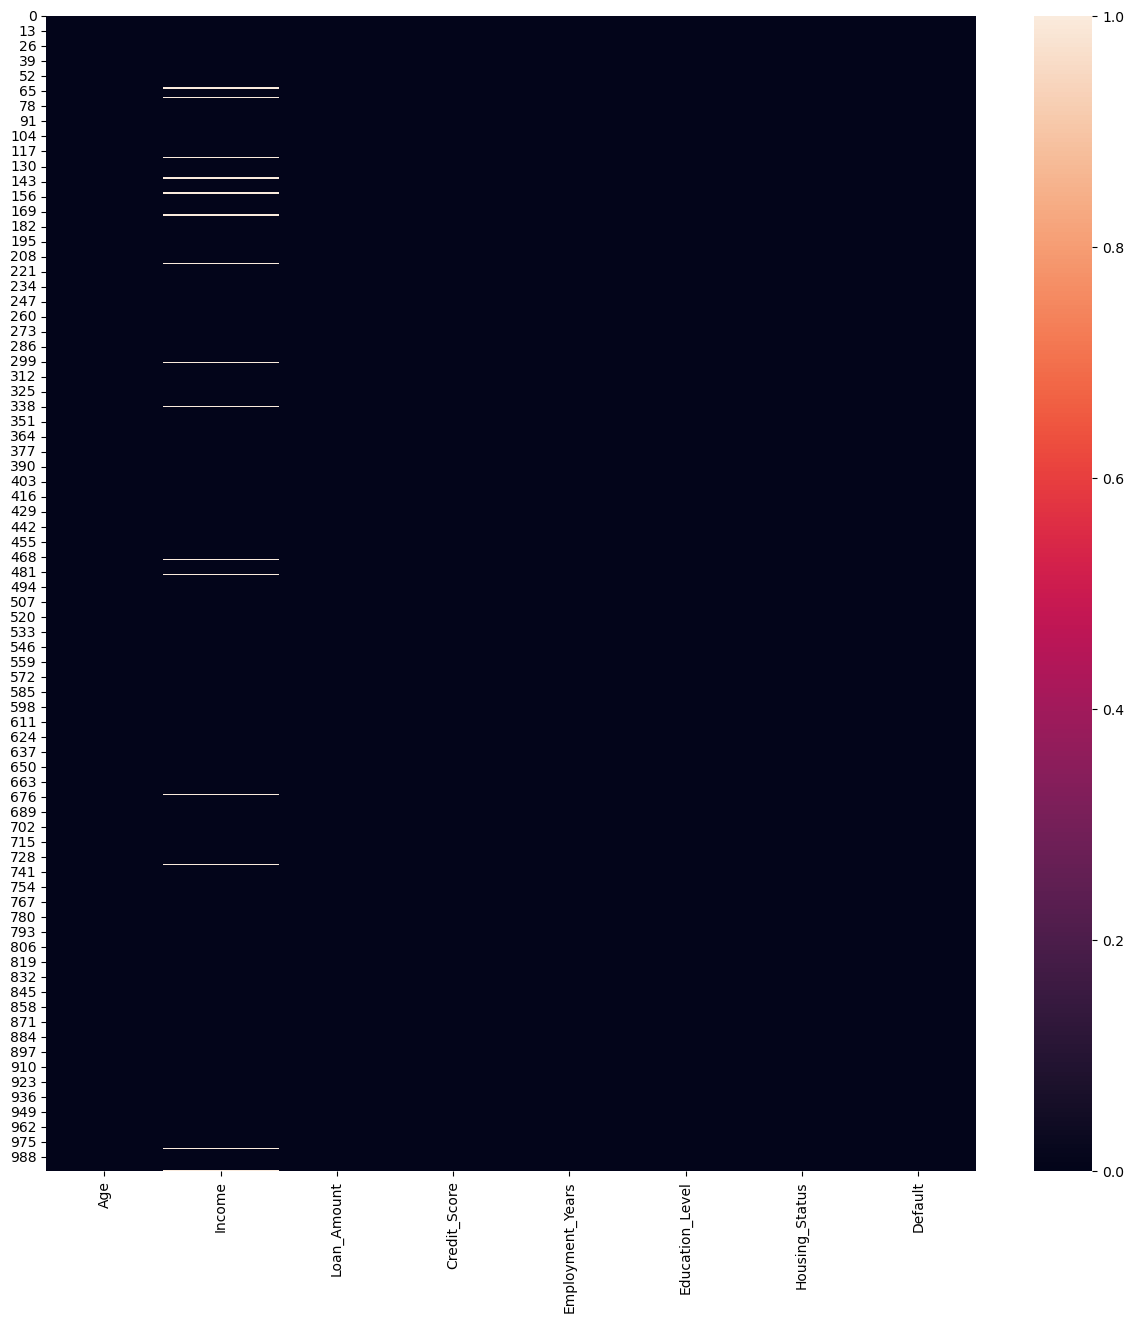

In [7]:
plt.figure(figsize=(15,15))
sns.heatmap(df.isnull())


In [8]:
df.isnull().sum()

Age                  0
Income              15
Loan_Amount          0
Credit_Score         0
Employment_Years     0
Education_Level      0
Housing_Status       0
Default              0
dtype: int64

In [9]:
df_null_clm = df.isnull().sum()/df.shape[0]*100
df_null_clm

Age                 0.0
Income              1.5
Loan_Amount         0.0
Credit_Score        0.0
Employment_Years    0.0
Education_Level     0.0
Housing_Status      0.0
Default             0.0
dtype: float64

In [10]:
df_null_clm[df_null_clm > 20]
null_clm_list = df_null_clm[df_null_clm > 20].index
null_clm_list

Index([], dtype='object')

In [11]:
df_drop_clm = df.drop(columns=null_clm_list)

In [12]:
df_num_clm = df_drop_clm.select_dtypes(include=['int','float'])

<Axes: >

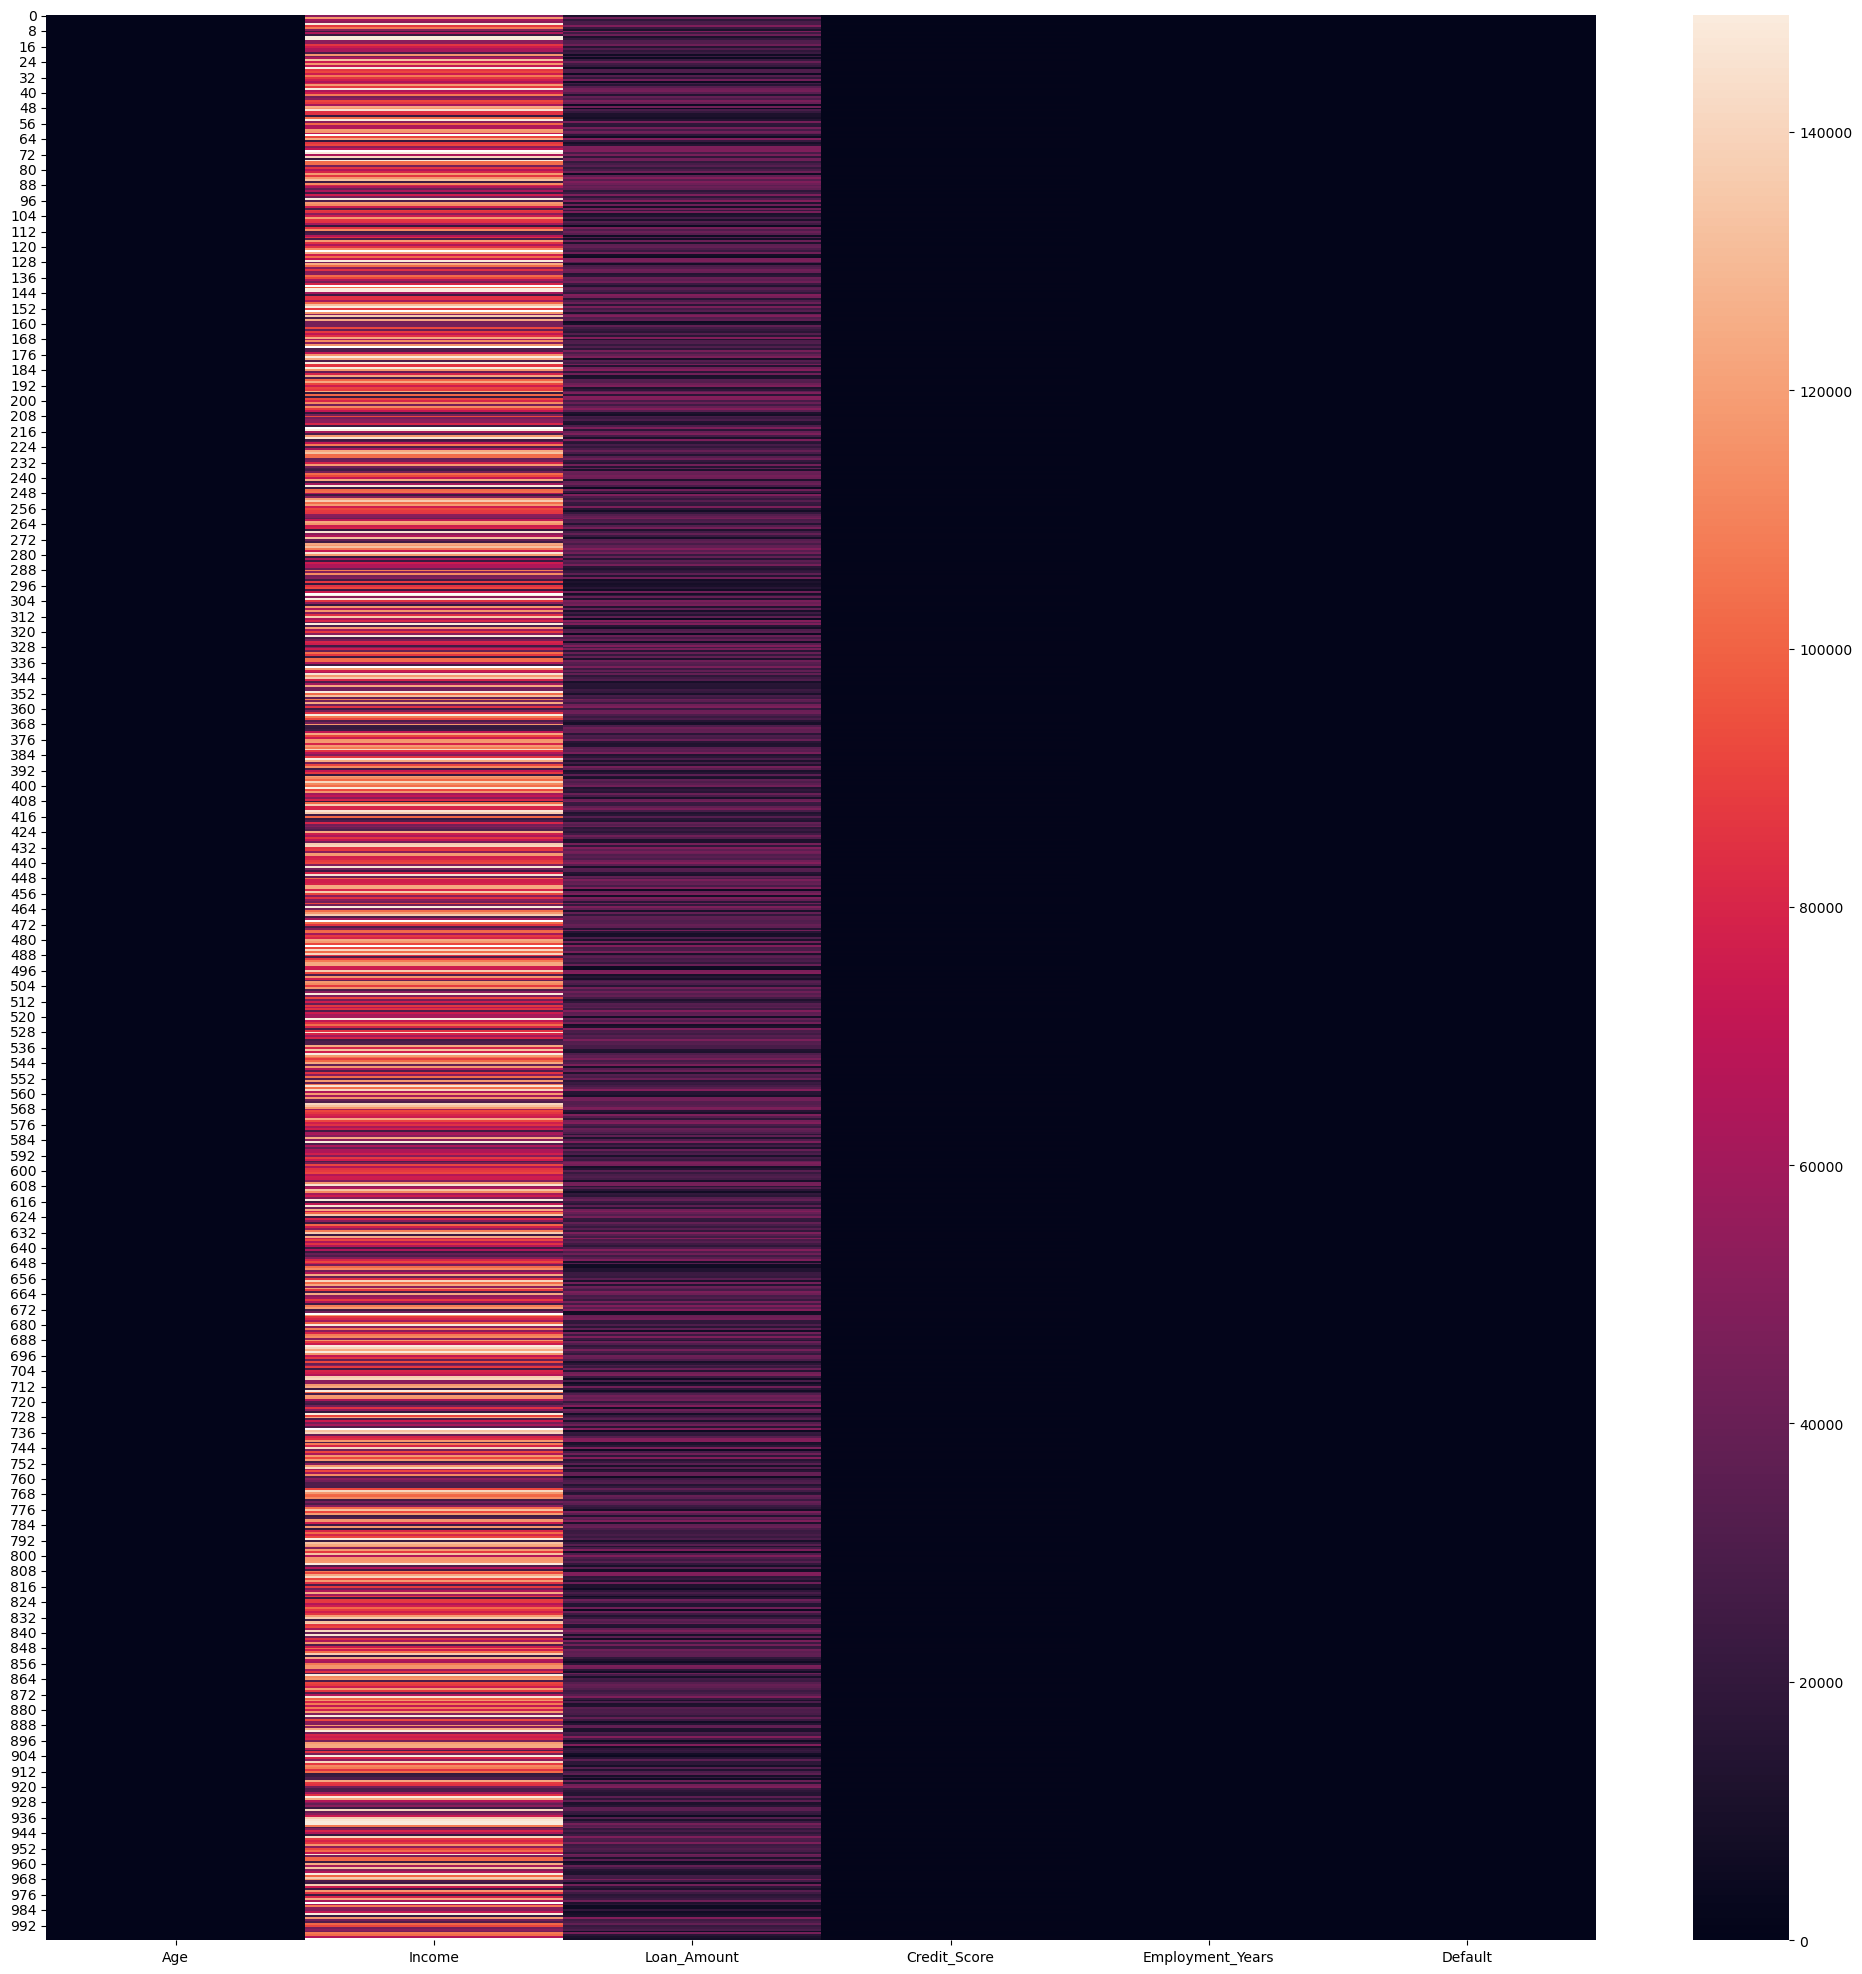

In [13]:
plt.figure(figsize=(25,25))
sns.heatmap(df_num_clm)

In [14]:
df_numeric = df_num_clm.dropna()


In [15]:
df_numeric.isnull().sum().sum()

np.int64(0)

<Axes: >

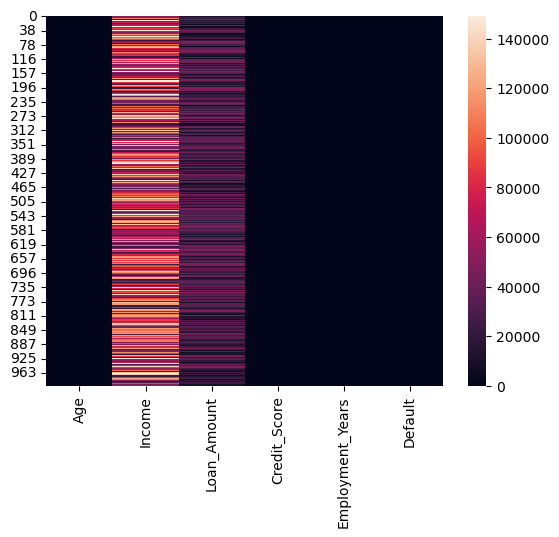

In [16]:
sns.heatmap(df_numeric)


In [17]:
df_cat = df_drop_clm.select_dtypes(include=['object'])

In [18]:
df_cat.isnull().sum().sum()

np.int64(0)

In [19]:
df_cat1 = df_cat.dropna()
df_cat1.isnull().sum().sum()

np.int64(0)

In [20]:
df_clean = df.dropna()

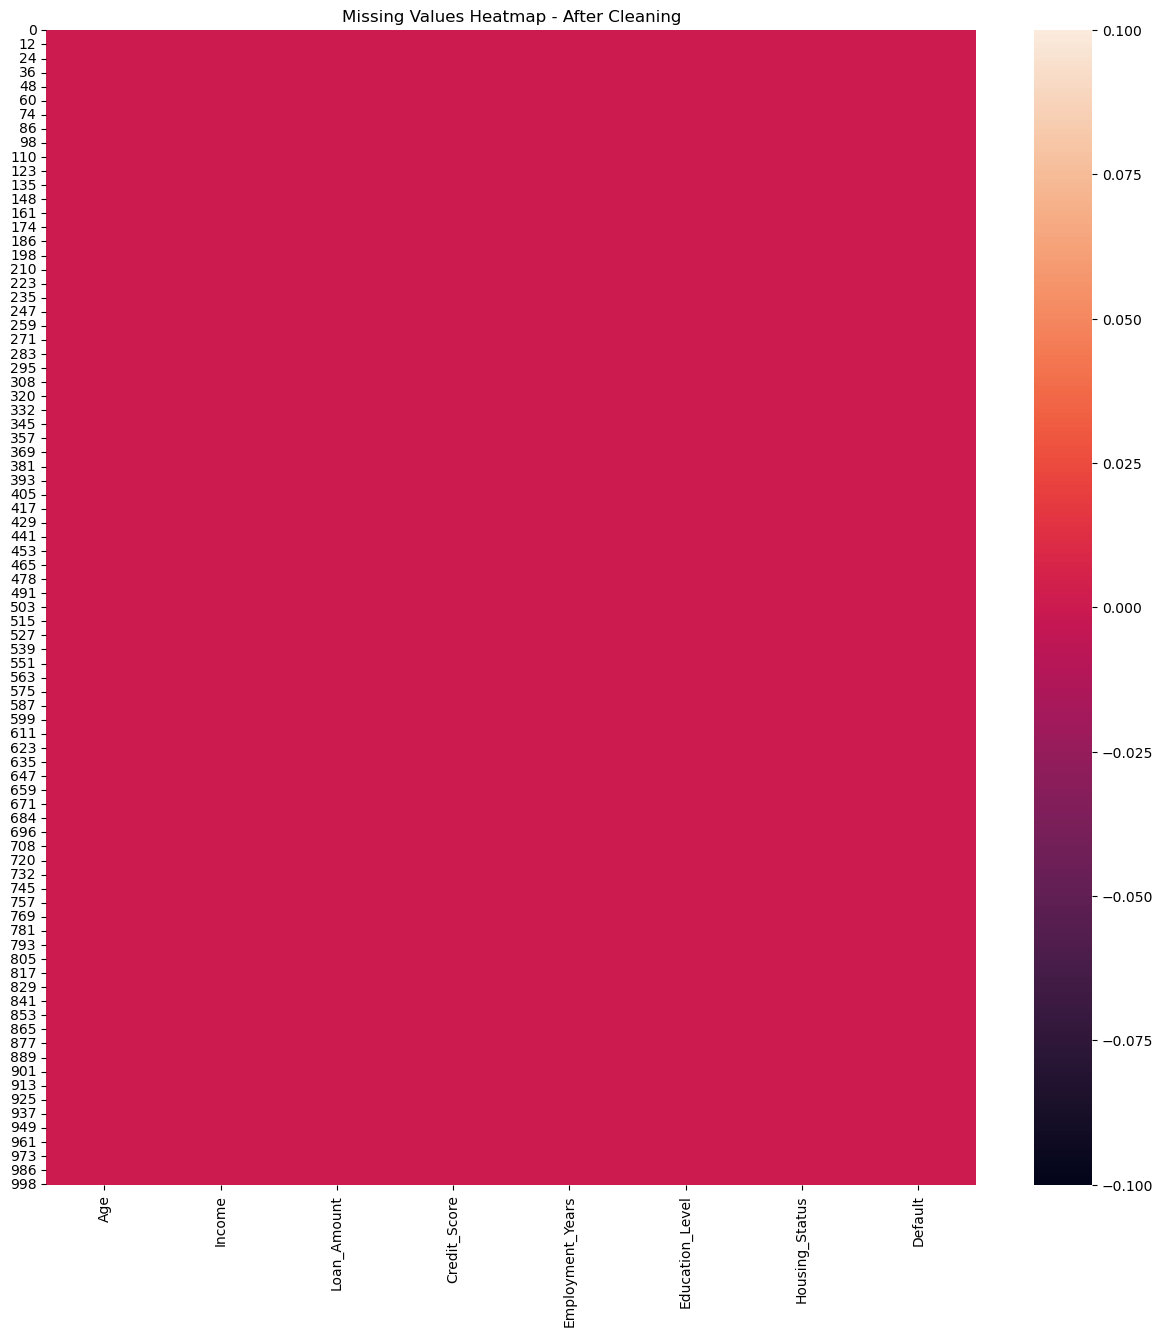

In [21]:
plt.figure(figsize=(15,15))
sns.heatmap(df_clean.isnull())
plt.title("Missing Values Heatmap - After Cleaning")
plt.show()

In [22]:
print("Final shape after cleaning:", df_clean.shape)
print("Total null values after cleaning:", df_clean.isnull().sum().sum())

Final shape after cleaning: (985, 8)
Total null values after cleaning: 0


In [23]:
print("\nDuplicate Rows :", df.duplicated().sum())


Duplicate Rows : 0


In [24]:
print(df.columns.tolist())

['Age', 'Income', 'Loan_Amount', 'Credit_Score', 'Employment_Years', 'Education_Level', 'Housing_Status', 'Default']


In [25]:
X = df.drop(columns=['Default'])
y = df['Default']

In [26]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [28]:
print(df.columns.tolist())

['Age', 'Income', 'Loan_Amount', 'Credit_Score', 'Employment_Years', 'Education_Level', 'Housing_Status', 'Default']


In [43]:
for col in df.columns:
    print(repr(col))

'Age'
'Income'
'Loan_Amount'
'Credit_Score'
'Employment_Years'
'Default'
'Education_Level_High School'
'Education_Level_Masters'
'Education_Level_PhD'
'Housing_Status_Own'
'Housing_Status_Rent'


In [42]:
print("Education_Level" in df.columns)
print("Housing_Status" in df.columns)

False
False


In [49]:
X = df.drop("Default", axis=1)
y = df["Default"]


In [36]:
print(type(df))
print(df.head())

<class 'pandas.core.frame.DataFrame'>
   Age    Income  Loan_Amount  Credit_Score  Employment_Years  Default  \
0   59   52154.0        11276           823                15        0   
1   49  116646.0        43663           315                 5        0   
2   35   61157.0        18994           428                 8        1   
3   63   52154.0        28499           408                26        0   
4   28  148876.0        28040           832                 3        1   

   Education_Level_High School  Education_Level_Masters  Education_Level_PhD  \
0                        False                    False                False   
1                        False                    False                 True   
2                        False                     True                False   
3                        False                    False                False   
4                        False                     True                False   

   Housing_Status_Own  Housing_Statu

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)


In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))